# Duffing Neural ODE — Step 3: odd-symmetry ablation

The forced Duffing right-hand side $\ddot{x} = x - x^3 - \delta\dot{x} + A$ is an **odd function of the triple** $(x, \dot{x}, A)$: negate all three and the acceleration negates. Since the network's input is $u = (x, \dot{x}, \cos\omega t, \sin\omega t)$ and flipping $A$ is just negating the phase pair, the true vector field satisfies $f(-u) = -f(u)$ — plain oddness in the network's input space.

We enforce this **architecturally** by antisymmetrizing the same MLP:

$$f_{\text{sym}}(u) = \tfrac{1}{2}\left(f_\theta(u) - f_\theta(-u)\right)$$

which is odd for *any* weights — the symmetry cannot be violated even before training.

**Ablation**: identical data (63-IC grid from Step 2), identical initialization, identical minibatch sequence, identical Adam schedule. The only difference is the wrapper. We compare:

1. **Learning speed** — full-dataset loss vs training step; steps to reach fixed loss thresholds
2. **Accuracy** — final loss, one-step errors, rollout error on held-out interior ICs
3. **Symmetry violation** — how far the baseline strays from oddness (the constrained net is exact by construction)
4. **Extrapolation breakdown** — the Step-2 rays, overlaid
5. **One-well stress test** — retrain both models on *right-well-settling trajectories only*, then roll out left-well ICs. This is where the symmetry should stop being a nicety and start doing real work.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DELTA, GAMMA, OMEGA = 0.5, 0.5, 1.7

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

T_END, DT_INT, DT_SAVE = 20.0, 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

X0_LIM, V0_LIM = 0.75, 0.4
ic_grid = np.stack(np.meshgrid(np.linspace(-X0_LIM, X0_LIM, 9),
                               np.linspace(-V0_LIM, V0_LIM, 7),
                               indexing='ij'), axis=-1).reshape(-1, 2)

sim_batch = jax.vmap(lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
trajs = np.asarray(sim_batch(jnp.asarray(ic_grid)))
print('training trajectories:', trajs.shape)

training trajectories: (63, 2001, 2)


## The two models

Shared MLP core (4 → 64 → 64 → 2, tanh, biases kept). The **baseline** calls it directly; the **odd** model wraps it with the antisymmetrizer. Note the odd model has the *same parameter count* — biases stay, and the wrapper simply discards the even part of the function, which for the true dynamics is provably zero.

In [2]:
LAYERS = [4, 64, 64, 2]

def init_params(key):
    params = []
    for n_in, n_out in zip(LAYERS[:-1], LAYERS[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

def make_input(s, t):
    return jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])

def rhs_base(params, s, t):
    return mlp(params, make_input(s, t))

def rhs_odd(params, s, t):
    u = make_input(s, t)
    return 0.5 * (mlp(params, u) - mlp(params, -u))

n_params = sum(W.size + b.size for W, b in init_params(jax.random.PRNGKey(0)))
print('parameters per model:', n_params)

parameters per model: 4610


## Training harness

One shared harness so the comparison is airtight: same initial weights (`PRNGKey(0)`), same minibatch index stream (`PRNGKey(1)` folded per step), same learning-rate schedule (1e-3 → 1e-4 at step 8000, 12000 steps total). Every 250 steps we evaluate the loss over **all 126k pairs** — batch loss is too noisy to compare convergence speed.

In [3]:
s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_grid)))
N_PAIRS = s_now.shape[0]
print('training pairs:', N_PAIRS)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

import os

BATCH = 16384
N_STEPS = 12000
EVAL_EVERY = 250

def train(rhs, tag, sn, sx, tn):
    n_pairs = sn.shape[0]

    def one_step(params, s, t):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb):
        pred = jax.vmap(lambda s, t: one_step(params, s, t))(sb, tb)
        return jnp.mean((pred - snb) ** 2)

    full_loss = jax.jit(lambda p: loss_on(p, sn, sx, tn))

    cache = f'params_{tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{tag}] loaded cached params from {cache}   '
              f'full loss {float(full_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], full_loss,
                float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, n_pairs)
        loss, grads = jax.value_and_grad(loss_on)(params, sn[idx],
                                                  sx[idx], tn[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_params(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= 8000 else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(full_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 2000 == 0:
                print(f'[{tag}] step {i:6d}   lr {lr:.0e}   full loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{tag}] final full loss {hist_loss[-1]:.3e}   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(W) for i, (W, _) in enumerate(params)},
             **{f'b{i}': np.asarray(b) for i, (_, b) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), full_loss, wall

params_base, steps_b, loss_b, full_loss_base, wall_b = train(
    rhs_base, 'baseline', s_now, s_next, t_now)
params_odd, steps_o, loss_o, full_loss_odd, wall_o = train(
    rhs_odd, 'odd', s_now, s_next, t_now)

training pairs: 126000


[baseline] loaded cached params from params_baseline.npz   full loss 1.804e-09   (delete the file to retrain)


[odd] loaded cached params from params_odd.npz   full loss 1.888e-09   (delete the file to retrain)


## 1 — Learning speed

Full-dataset loss vs Adam step, plus the number of steps each model needs to first cross fixed loss thresholds. If the symmetry constraint helps optimization, the odd curve should sit below the baseline at equal step count.

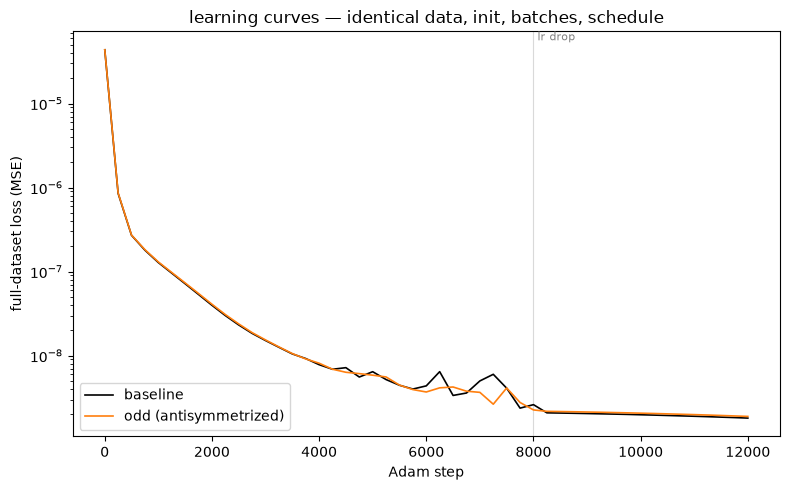

steps to first reach loss threshold:
   threshold   baseline        odd
       1e-06        250        250
       1e-07       1250       1250
       1e-08       3750       3750
       3e-09       7750       7250

final loss   baseline 1.804e-09   odd 1.888e-09   ratio 0.96x
wall time    baseline 136 s        odd 354 s  (odd runs 2 forward passes per eval)


In [4]:
fig, a = plt.subplots(figsize=(8, 5))
a.semilogy(steps_b, loss_b, 'k', lw=1.2, label='baseline')
a.semilogy(steps_o, loss_o, color='tab:orange', lw=1.2, label='odd (antisymmetrized)')
a.axvline(8000, color='0.85', lw=0.8, zorder=0)
a.text(8000, a.get_ylim()[1], ' lr drop', va='top', fontsize=8, color='0.5')
a.set_xlabel('Adam step')
a.set_ylabel('full-dataset loss (MSE)')
a.set_title('learning curves — identical data, init, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print('steps to first reach loss threshold:')
print(f'{"threshold":>12s} {"baseline":>10s} {"odd":>10s}')
for thr in [1e-6, 1e-7, 1e-8, 3e-9]:
    def first(steps, loss):
        hit = np.nonzero(loss <= thr)[0]
        return f'{steps[hit[0]]:d}' if hit.size else '—'
    print(f'{thr:>12.0e} {first(steps_b, loss_b):>10s} {first(steps_o, loss_o):>10s}')

print()
print(f'final loss   baseline {loss_b[-1]:.3e}   odd {loss_o[-1]:.3e}'
      f'   ratio {loss_b[-1] / loss_o[-1]:.2f}x')
print(f'wall time    baseline {wall_b:.0f} s        odd {wall_o:.0f} s'
      f'  (odd runs 2 forward passes per eval)')

## 2 — Accuracy: one-step errors and held-out ICs

One-step prediction error over all 126k pairs, then free 20 s rollouts from the five held-out interior ICs used in Step 2.

In [5]:
def one_step_errors(rhs, params):
    f = lambda s, t: rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)
    pred = jax.vmap(f)(s_now, t_now)
    return np.asarray(jnp.linalg.norm(pred - s_next, axis=1))

for tag, rhs, p in [('baseline', rhs_base, params_base),
                    ('odd     ', rhs_odd, params_odd)]:
    e = one_step_errors(rhs, p)
    print(f'{tag} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

INTERP_ICS = [(0.33, 0.17), (-0.61, -0.29), (0.05, -0.37), (0.7, 0.35), (-0.5, 0.0)]

def rollout_err(rhs, params, ic):
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    same_well = (tru[-1, 0] > 0) == (rol[-1, 0] > 0)
    return err.mean(), same_well

print()
print('held-out IC rollouts (mean error over 20 s):')
print(f'{"IC":>16s} {"baseline":>12s} {"odd":>12s}   wells correct?')
for ic in INTERP_ICS:
    eb, wb = rollout_err(rhs_base, params_base, ic)
    eo, wo = rollout_err(rhs_odd, params_odd, ic)
    print(f'{str(ic):>16s} {eb:>12.2e} {eo:>12.2e}   {wb} / {wo}')

baseline one-step error   median 2.45e-05   mean 4.03e-05   max 4.22e-04
odd      one-step error   median 2.31e-05   mean 4.06e-05   max 4.52e-04

held-out IC rollouts (mean error over 20 s):
              IC     baseline          odd   wells correct?


    (0.33, 0.17)     3.24e-03     3.78e-03   True / True
  (-0.61, -0.29)     3.54e-03     7.62e-03   True / True


   (0.05, -0.37)     6.81e-03     5.44e-03   True / True
     (0.7, 0.35)     2.51e-03     3.60e-03   True / True


     (-0.5, 0.0)     8.16e-03     5.14e-03   True / True


## 3 — Symmetry violation

Measure $\|f(u) + f(-u)\|$ — exactly zero for an odd function — on a grid of states $x, \dot{x} \in [-2, 2]$ at 8 forcing phases (taking the worst phase per state). For the baseline this is its *even part*: a component we know analytically should not exist, so all of it is error. The antisymmetrized model is odd to the last bit by construction.

baseline symmetry violation   median 4.60e-02   max 1.06e-01
odd      symmetry violation   median 7.02e-16   max 2.70e-15


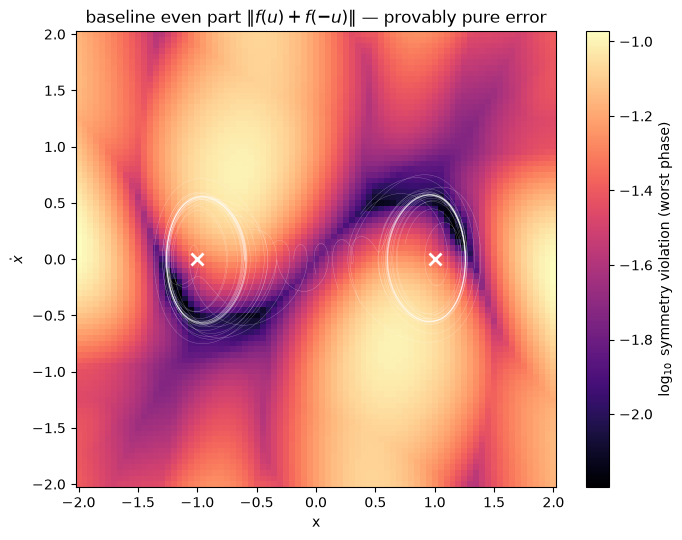

In [6]:
xs = np.linspace(-2, 2, 81)
vs = np.linspace(-2, 2, 81)
phases = np.arange(8) * (2 * np.pi / 8) / OMEGA   # 8 times spanning one period
X, V = np.meshgrid(xs, vs, indexing='ij')
states = jnp.asarray(np.stack([X.ravel(), V.ravel()], axis=1))

def violation(rhs, params):
    def at_phase(t):
        f_pos = jax.vmap(lambda s: rhs(params, s, t))(states)
        f_neg = jax.vmap(lambda s: rhs(params, -s, t + np.pi / OMEGA))(states)
        return jnp.linalg.norm(f_pos + f_neg, axis=1)
    return np.asarray(jnp.stack([at_phase(t) for t in phases]).max(axis=0)
                      ).reshape(X.shape)

viol_base = violation(rhs_base, params_base)
viol_odd = violation(rhs_odd, params_odd)
print(f'baseline symmetry violation   median {np.median(viol_base):.2e}'
      f'   max {viol_base.max():.2e}')
print(f'odd      symmetry violation   median {np.median(viol_odd):.2e}'
      f'   max {viol_odd.max():.2e}')

fig, a = plt.subplots(figsize=(7, 5.5))
im = a.pcolormesh(xs, vs, np.log10(np.maximum(viol_base, 1e-18)).T,
                  cmap='magma', shading='auto')
plt.colorbar(im, ax=a, label=r'$\log_{10}$ symmetry violation (worst phase)')
for tr in trajs[::6]:
    a.plot(tr[:, 0], tr[:, 1], color='w', lw=0.2, alpha=0.5)
a.plot([-1, 1], [0, 0], 'x', color='w', ms=9, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('baseline even part $\\|f(u) + f(-u)\\|$ — provably pure error')
plt.tight_layout(); plt.show()

## 4 — Extrapolation breakdown, overlaid

The Step-2 rays, both models on the same axes. The odd model's predictions at $(-x_0, 0)$ launched at phase $\pi$ would be *exact mirrors* of $(x_0, 0)$ at phase 0; launched at phase 0 (as here) real physical asymmetry remains, but the *model-error* contribution to the asymmetry should shrink, and the left side now benefits from every right-side data point.

### Where the data actually lives

The IC box only marks where trajectories **start** — every trajectory then sweeps through a much larger region of state space, and the model has real information everywhere it was swept. A ray IC outside the box is not necessarily out-of-distribution: it may sit squarely inside the painted tube.

The heat map below is the kernel-smoothed density of all 126k training states (bandwidth 0.08 in state units, log shading): **darker = more data near that exact $(x, \dot{x})$ point**, lighter = less. The extrapolation rays in the next figure carry this same coverage as a background strip, so breakdown can be read against where the *data* ends rather than where the *box* ends.

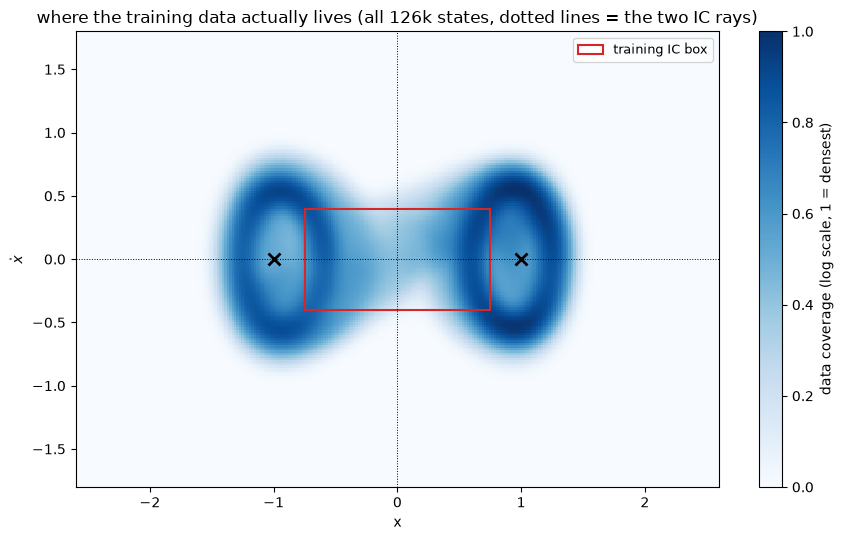

training-state ranges:  x in [-1.42, +1.40]   xdot in [-0.78, +0.79]


In [7]:
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle, Patch

pts = np.asarray(s_now)                     # all 126k training states (x, xdot)
BIN = 0.02
SIG = 0.08                                  # kernel width in state units
XB = np.arange(-2.6, 2.6 + 1e-9, BIN)
VB = np.arange(-1.8, 1.8 + 1e-9, BIN)
H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[XB, VB])
D_log = np.log10(1.0 + gaussian_filter(H, SIG / BIN))
D_norm = D_log / D_log.max()

xc = 0.5 * (XB[:-1] + XB[1:])
vc = 0.5 * (VB[:-1] + VB[1:])

def coverage_at(x, v):
    i = np.clip(np.searchsorted(xc, x), 0, len(xc) - 1)
    j = np.clip(np.searchsorted(vc, v), 0, len(vc) - 1)
    return D_norm[i, j]

fig, a = plt.subplots(figsize=(9, 5.5))
im = a.pcolormesh(XB, VB, D_norm.T, cmap='Blues', shading='auto',
                  vmin=0, vmax=1)
plt.colorbar(im, ax=a, label='data coverage (log scale, 1 = densest)')
a.add_patch(Rectangle((-X0_LIM, -V0_LIM), 2 * X0_LIM, 2 * V0_LIM,
                      fill=False, edgecolor='tab:red', lw=1.5,
                      label='training IC box'))
a.axhline(0, color='k', lw=0.7, ls=':')
a.axvline(0, color='k', lw=0.7, ls=':')
a.plot([-1, 1], [0, 0], 'x', color='k', ms=9, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('where the training data actually lives '
            '(all 126k states, dotted lines = the two IC rays)')
a.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print(f'training-state ranges:  x in [{pts[:, 0].min():+.2f}, '
      f'{pts[:, 0].max():+.2f}]   xdot in [{pts[:, 1].min():+.2f}, '
      f'{pts[:, 1].max():+.2f}]')

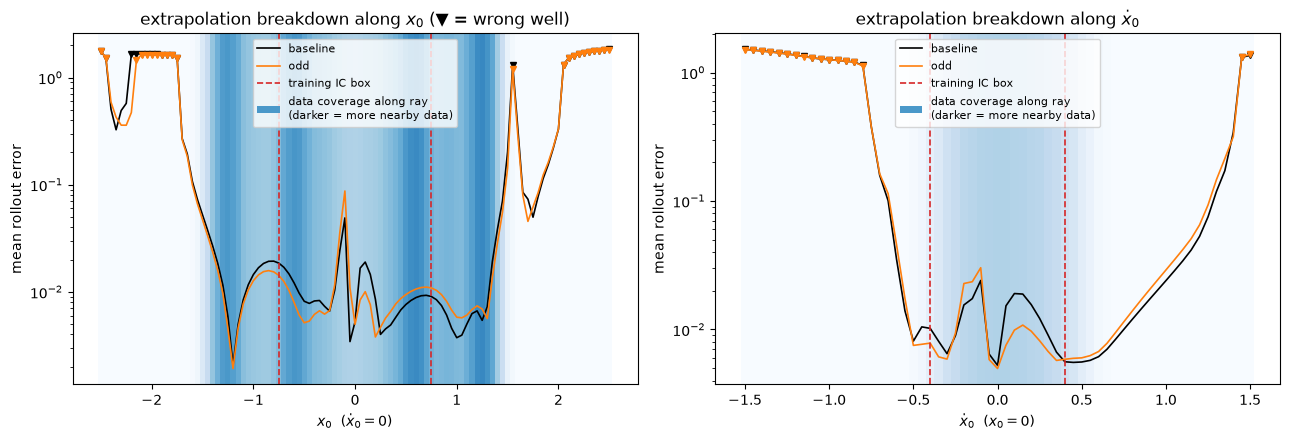

--- ray along x0 ---
  baseline  median err 1.91e-02   wrong-well starts: 23/101
  odd       median err 1.54e-02   wrong-well starts: 22/101
--- ray along v0 ---
  baseline  median err 2.40e-02   wrong-well starts: 17/61
  odd       median err 2.90e-02   wrong-well starts: 17/61


In [8]:
def ray_errors(rhs, params, ics):
    ics = jnp.asarray(ics)
    f = lambda s, t: rhs(params, s, t)
    tru = np.asarray(jax.vmap(
        lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(ics))
    rol = np.asarray(jax.vmap(
        lambda s0: simulate(f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))
    err = np.linalg.norm(rol - tru, axis=2).mean(axis=1)
    wrong_well = (tru[:, -1, 0] > 0) != (rol[:, -1, 0] > 0)
    return err, wrong_well

x_ray = np.linspace(-2.5, 2.5, 101)
v_ray = np.linspace(-1.5, 1.5, 61)
rays = {'x': np.stack([x_ray, np.zeros_like(x_ray)], axis=1),
        'v': np.stack([np.zeros_like(v_ray), v_ray], axis=1)}
res = {}
for tag, rhs, p in [('baseline', rhs_base, params_base),
                    ('odd', rhs_odd, params_odd)]:
    res[tag] = {k: ray_errors(rhs, p, ics) for k, ics in rays.items()}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, key, ray, lim, name in [
        (ax[0], 'x', x_ray, X0_LIM, '$x_0$  ($\\dot{x}_0 = 0$)'),
        (ax[1], 'v', v_ray, V0_LIM, '$\\dot{x}_0$  ($x_0 = 0$)')]:
    cov = coverage_at(rays[key][:, 0], rays[key][:, 1])
    dr = ray[1] - ray[0]
    for xi, ci in zip(ray, cov):
        a.axvspan(xi - dr / 2, xi + dr / 2,
                  color=plt.cm.Blues(0.75 * ci), lw=0, zorder=0)
    for tag, color in [('baseline', 'k'), ('odd', 'tab:orange')]:
        err, ww = res[tag][key]
        a.semilogy(ray, err, color=color, lw=1.2, label=tag)
        a.semilogy(ray[ww], err[ww], 'v', color=color, ms=5)
    a.axvline(-lim, color='tab:red', lw=1.2, ls='--')
    a.axvline(lim, color='tab:red', lw=1.2, ls='--', label='training IC box')
    a.set_xlabel(name); a.set_ylabel('mean rollout error')
    handles, _ = a.get_legend_handles_labels()
    handles.append(Patch(facecolor=plt.cm.Blues(0.6),
                         label='data coverage along ray\n(darker = more nearby data)'))
    a.legend(handles=handles, loc='upper center', fontsize=8)
ax[0].set_title('extrapolation breakdown along $x_0$ (▼ = wrong well)')
ax[1].set_title('extrapolation breakdown along $\\dot{x}_0$')
plt.tight_layout(); plt.show()

for key, ray in [('x', x_ray), ('v', v_ray)]:
    print(f'--- ray along {key}0 ---')
    for tag in ['baseline', 'odd']:
        err, ww = res[tag][key]
        n_ww = int(ww.sum())
        print(f'  {tag:9s} median err {np.median(err):.2e}'
              f'   wrong-well starts: {n_ww}/{len(ray)}')

### Two breakdown trajectories, up close

Two ICs from the $x_0$ ray, chosen automatically from the baseline's results, showing the two distinct failure modes:

1. **Wrong well** — the wrong-well start *closest to the training box* (the most surprising failure). Both models track the truth through the initial plunge, then make the wrong call at the barrier and orbit the wrong attractor forever: a tiny model error near the basin boundary flips a discrete, irreversible choice.
2. **Right well, high error** — the correct-well start with the *largest* error. Deep extrapolation: the true swing reaches speeds far outside the data, so the transient is badly wrong — but the driven period-1 attractor is phase-locked to the forcing, so once the model falls into the correct well it re-synchronizes and the late-time error collapses.

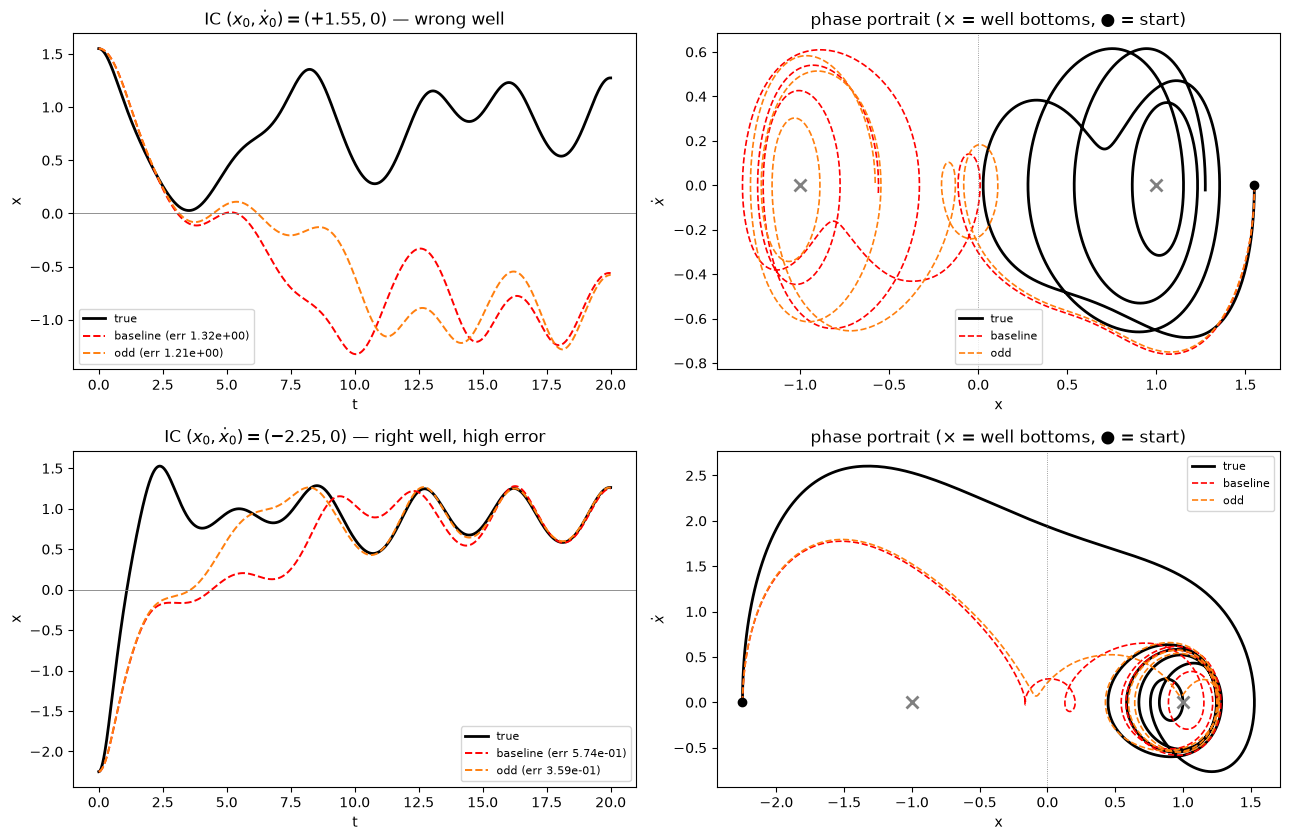

In [9]:
err_bx, ww_bx = res['baseline']['x']
ww_idx = np.where(ww_bx)[0]
pick_ww = ww_idx[np.argmin(np.abs(np.abs(x_ray[ww_idx]) - X0_LIM))]
outside = np.abs(x_ray) > X0_LIM
cand = np.where(outside & ~ww_bx)[0]
pick_he = cand[np.argmax(err_bx[cand])]

picks = [(x_ray[pick_ww], 'wrong well'),
         (x_ray[pick_he], 'right well, high error')]

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for row, (x0, label) in enumerate(picks):
    s0 = jnp.array([x0, 0.0])
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rb = np.asarray(simulate(lambda s, t: rhs_base(params_base, s, t),
                             s0, 0.0, N_SAVE, DT_SAVE, 1))
    ro = np.asarray(simulate(lambda s, t: rhs_odd(params_odd, s, t),
                             s0, 0.0, N_SAVE, DT_SAVE, 1))
    eb = np.linalg.norm(rb - tru, axis=1).mean()
    eo = np.linalg.norm(ro - tru, axis=1).mean()

    a = axes[row, 0]
    a.plot(times, tru[:, 0], 'k', lw=2, label='true')
    a.plot(times, rb[:, 0], 'r--', lw=1.4, label=f'baseline (err {eb:.2e})')
    a.plot(times, ro[:, 0], color='tab:orange', ls='--', lw=1.4,
           label=f'odd (err {eo:.2e})')
    a.axhline(0, color='gray', lw=0.6)
    a.set_xlabel('t'); a.set_ylabel('x')
    a.set_title(f'IC $(x_0, \\dot{{x}}_0) = ({x0:+.2f}, 0)$ — {label}')
    a.legend(fontsize=8)

    a = axes[row, 1]
    a.plot(tru[:, 0], tru[:, 1], 'k', lw=2, label='true')
    a.plot(rb[:, 0], rb[:, 1], 'r--', lw=1.2, label='baseline')
    a.plot(ro[:, 0], ro[:, 1], color='tab:orange', ls='--', lw=1.2,
           label='odd')
    a.plot([-1, 1], [0, 0], 'x', color='gray', ms=9, mew=2)
    a.axvline(0, color='gray', lw=0.6, ls=':')
    a.plot(tru[0, 0], tru[0, 1], 'ko', ms=6)
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
    a.set_title('phase portrait (× = well bottoms, ● = start)')
    a.legend(fontsize=8)

plt.tight_layout(); plt.show()

### Settling speed: barrier-top start vs near-attractor start

$(-1.2, 0)$ is the *easiest* IC on the entire $x_0$ ray (mean error $\approx 2\times10^{-3}$, smaller than any interior point) even though it lies outside the IC box. The comparison with the barrier-top start $(0, 0)$ shows why: $(-1.2, 0)$ begins just past the left well bottom, essentially on top of the attractor — one short relaxation and the trajectory spends all 20 s on the phase-locked limit cycle, exactly where training data is densest. $(0, 0)$ balances on the barrier and rides a long, large-amplitude transient near the basin boundary before committing to a well; most of its error accumulates during that transient. Mean rollout error is dominated by *transient duration*, and the transient is short when you start near an attractor — in-distribution thanks to the overshoot coverage above.

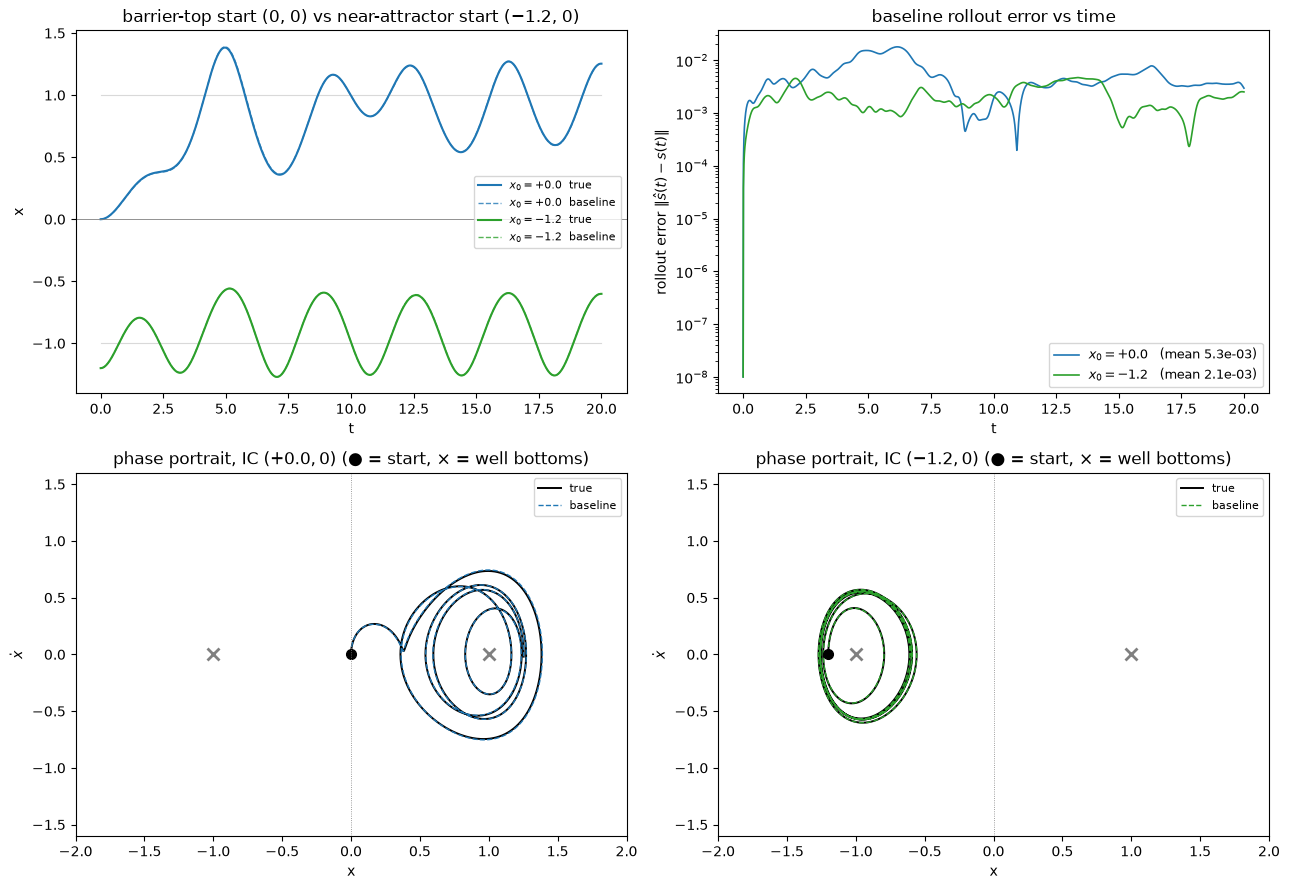

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
a0, a1 = axes[0]
for col, (x0, color) in enumerate([(0.0, 'tab:blue'), (-1.2, 'tab:green')]):
    s0 = jnp.array([x0, 0.0])
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(lambda s, t: rhs_base(params_base, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    a0.plot(times, tru[:, 0], color=color, lw=1.5,
            label=f'$x_0 = {x0:+.1f}$  true')
    a0.plot(times, rol[:, 0], color=color, ls='--', lw=1.0, alpha=0.8,
            label=f'$x_0 = {x0:+.1f}$  baseline')
    a1.semilogy(times, np.maximum(err, 1e-8), color=color, lw=1.2,
                label=f'$x_0 = {x0:+.1f}$   (mean {err.mean():.1e})')

    a = axes[1, col]
    a.plot(tru[:, 0], tru[:, 1], color='k', lw=1.4, label='true')
    a.plot(rol[:, 0], rol[:, 1], color=color, ls='--', lw=1.0,
           label='baseline')
    a.plot(tru[0, 0], tru[0, 1], 'o', color='k', ms=7)
    a.plot([-1, 1], [0, 0], 'x', color='gray', ms=9, mew=2)
    a.axvline(0, color='gray', lw=0.6, ls=':')
    a.set_xlim(-2.0, 2.0); a.set_ylim(-1.6, 1.6)
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
    a.set_title(f'phase portrait, IC $({x0:+.1f}, 0)$ '
                '(● = start, × = well bottoms)')
    a.legend(fontsize=8)

a0.axhline(0, color='gray', lw=0.6)
a0.plot([0, T_END], [-1, -1], color='0.85', lw=0.8, zorder=0)
a0.plot([0, T_END], [1, 1], color='0.85', lw=0.8, zorder=0)
a0.set_xlabel('t'); a0.set_ylabel('x')
a0.set_title('barrier-top start (0, 0) vs near-attractor start (−1.2, 0)')
a0.legend(fontsize=8)
a1.set_xlabel('t')
a1.set_ylabel(r'rollout error $\|\hat{s}(t) - s(t)\|$')
a1.set_title('baseline rollout error vs time')
a1.legend(fontsize=9)
plt.tight_layout(); plt.show()

### The double-well potential and the energy budget

Only the **position-dependent** part of the force comes from a potential. Splitting the acceleration,

$$\ddot{x} = \underbrace{(x - x^3)}_{-\,dU/dx} \; \underbrace{-\,\delta\dot{x}}_{\text{damping}} \; \underbrace{+\,\gamma\cos\omega t}_{\text{drive}},$$

and integrating $-dU/dx = x - x^3$ gives

$$U(x) = -\tfrac{x^2}{2} + \tfrac{x^4}{4}$$

— barrier top at $x=0$ ($U=0$), well bottoms at $x=\pm 1$ ($U=-\tfrac14$). The damping term **cannot** be absorbed into $U$: potentials depend on position only, and a force derived from one conserves energy, which is exactly what damping doesn't do. $\dot{x}$ instead enters through the energy $E = \tfrac12\dot{x}^2 + U(x)$ and its budget along a trajectory,

$$\frac{dE}{dt} = -\delta\dot{x}^2 + \gamma\dot{x}\cos\omega t,$$

where damping always drains and the drive pumps or drains depending on sign alignment. The potential shapes *where* the wells are; damping is what *sinks* you into one; the drive keeps you sloshing on a limit cycle near the bottom instead of coming to rest. Right panel: $E(t)$ for the two ICs above — both relax to the same small oscillation just above the well-bottom energy $-\tfrac14$.

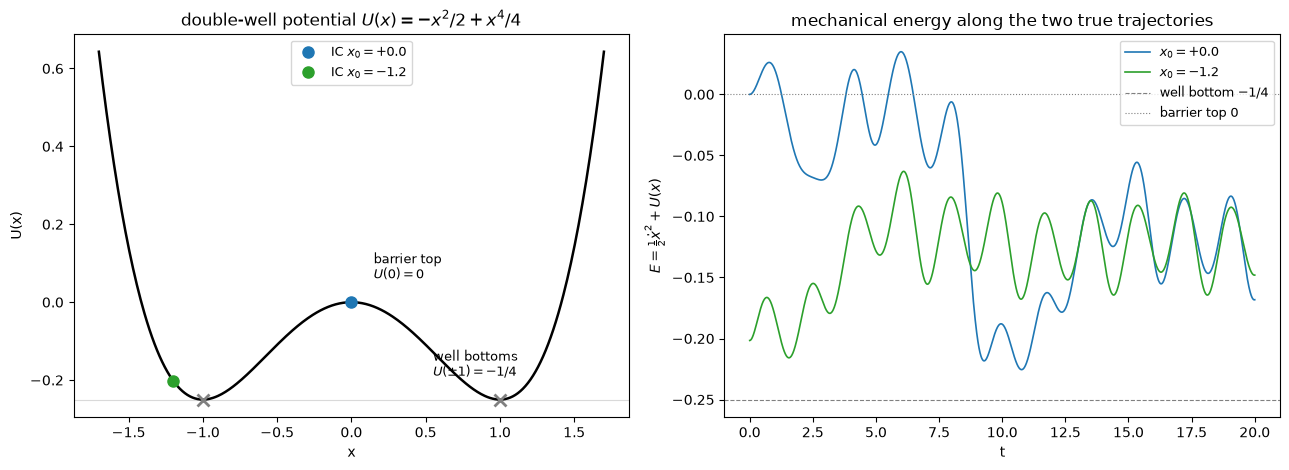

In [11]:
def U(x):
    return -x**2 / 2 + x**4 / 4

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

a = axes[0]
xu = np.linspace(-1.7, 1.7, 400)
a.plot(xu, U(xu), 'k', lw=1.8)
a.plot([-1, 1], [U(-1), U(1)], 'x', color='gray', ms=9, mew=2)
a.plot([0], [0], 'o', color='gray', ms=6, mfc='none')
a.axhline(-0.25, color='0.85', lw=0.8, zorder=0)
a.annotate('barrier top\n$U(0) = 0$', (0, 0), (0.15, 0.06), fontsize=9)
a.annotate('well bottoms\n$U(\\pm 1) = -1/4$', (1, -0.25), (0.55, -0.19),
           fontsize=9)
for x0, color in [(0.0, 'tab:blue'), (-1.2, 'tab:green')]:
    a.plot([x0], [U(x0)], 'o', color=color, ms=8,
           label=f'IC $x_0 = {x0:+.1f}$')
a.set_xlabel('x'); a.set_ylabel('U(x)')
a.set_title('double-well potential $U(x) = -x^2/2 + x^4/4$')
a.legend(fontsize=9)

a = axes[1]
for x0, color in [(0.0, 'tab:blue'), (-1.2, 'tab:green')]:
    tru = np.asarray(simulate(true_rhs, jnp.array([x0, 0.0]),
                              0.0, N_SAVE, DT_SAVE, SUBS))
    E = 0.5 * tru[:, 1]**2 + U(tru[:, 0])
    a.plot(times, E, color=color, lw=1.2, label=f'$x_0 = {x0:+.1f}$')
a.axhline(-0.25, color='gray', lw=0.8, ls='--', label='well bottom $-1/4$')
a.axhline(0, color='gray', lw=0.8, ls=':', label='barrier top $0$')
a.set_xlabel('t')
a.set_ylabel(r'$E = \frac{1}{2}\dot{x}^2 + U(x)$')
a.set_title('mechanical energy along the two true trajectories')
a.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5 — One-well stress test: train on right-well trajectories only

With all 63 trajectories, both wells are densely painted and the data already *teaches* the symmetry — so enforcing it architecturally buys little. The constraint should matter when the data is one-sided. Here we retrain both models **from scratch on only the trajectories that settle in the right well**, then roll out ICs that settle in the left well.

The right-settling trajectories do wander through $x<0$ during their transients, but the **left limit-cycle tube is never painted**. The baseline has no information there and must invent the left well. The odd model gets the left well *for free*: every state in the left tube is the mirror of a densely-painted right-tube state at the opposite forcing phase, and oddness transfers the prediction exactly.

In [12]:
right_mask = trajs[:, -1, 0] > 0
trajs_R = trajs[right_mask]
print(f'training on {trajs_R.shape[0]}/63 trajectories (right-well only)')

sR_now = jnp.asarray(trajs_R[:, :-1, :].reshape(-1, 2))
sR_next = jnp.asarray(trajs_R[:, 1:, :].reshape(-1, 2))
tR_now = jnp.asarray(np.tile(times[:-1], trajs_R.shape[0]))
print('training pairs:', sR_now.shape[0])

params_base_R, *_ = train(rhs_base, 'baseline-R', sR_now, sR_next, tR_now)
params_odd_R, *_ = train(rhs_odd, 'odd-R', sR_now, sR_next, tR_now)

training on 35/63 trajectories (right-well only)
training pairs: 70000


[baseline-R] loaded cached params from params_baseline-R.npz   full loss 2.104e-09   (delete the file to retrain)


[odd-R] loaded cached params from params_odd-R.npz   full loss 2.029e-09   (delete the file to retrain)


### Rollouts from all 28 left-settling grid ICs

Every training-grid IC whose *true* trajectory settles in the left well — territory the retrained models never saw painted.

In [13]:
left_ics = jnp.asarray(ic_grid[~np.asarray(right_mask)])

def batch_rollout(rhs, params, ics):
    f = lambda s, t: rhs(params, s, t)
    return np.asarray(jax.vmap(
        lambda s0: simulate(f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))

tru_L = np.asarray(jax.vmap(
    lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(left_ics))

print(f'{"model":>12s} {"median err":>12s} {"max err":>10s}   wrong final well')
for tag, rhs, p in [('baseline-R', rhs_base, params_base_R),
                    ('odd-R', rhs_odd, params_odd_R)]:
    rol = batch_rollout(rhs, p, left_ics)
    err = np.linalg.norm(rol - tru_L, axis=2).mean(axis=1)
    ww = (tru_L[:, -1, 0] > 0) != (rol[:, -1, 0] > 0)
    print(f'{tag:>12s} {np.median(err):>12.2e} {err.max():>10.2e}'
          f'   {int(ww.sum())}/{len(left_ics)}')

       model   median err    max err   wrong final well


  baseline-R     1.49e+00   1.60e+00   21/28


       odd-R     1.09e-02   7.96e-02   0/28


### One left-well IC in detail

A deep-left start $(-1.2, 0)$ — inside the left limit-cycle tube, maximally far from any right-well training data.

  baseline-R   mean err 1.65e+00   final err 1.86e+00
       odd-R   mean err 2.40e-03   final err 1.77e-03


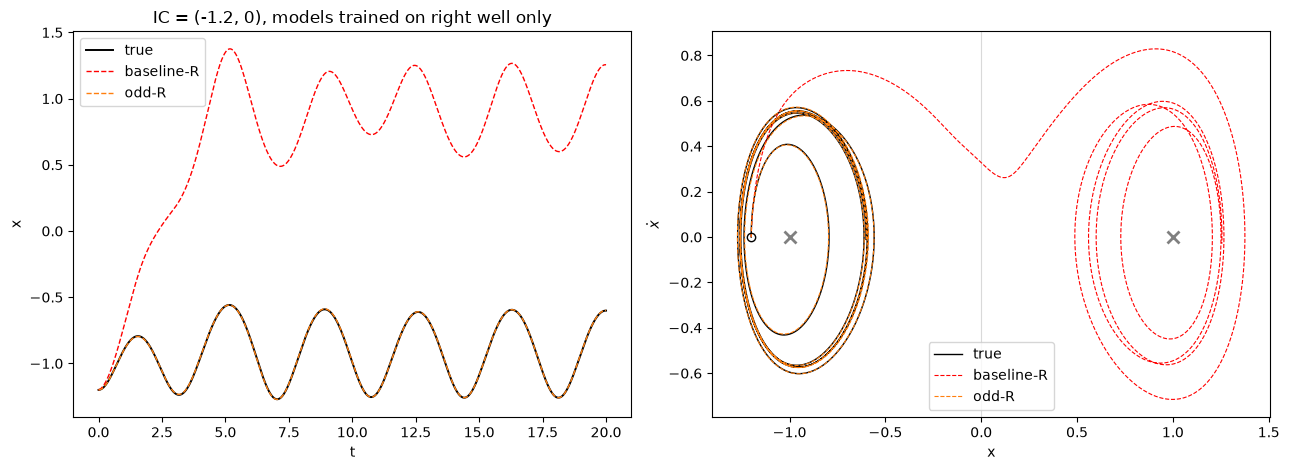

In [14]:
ic = jnp.array([-1.2, 0.0])
tru = np.asarray(simulate(true_rhs, ic, 0.0, N_SAVE, DT_SAVE, SUBS))
rol_b = np.asarray(simulate(lambda s, t: rhs_base(params_base_R, s, t),
                            ic, 0.0, N_SAVE, DT_SAVE, 1))
rol_o = np.asarray(simulate(lambda s, t: rhs_odd(params_odd_R, s, t),
                            ic, 0.0, N_SAVE, DT_SAVE, 1))
for tag, rol in [('baseline-R', rol_b), ('odd-R', rol_o)]:
    err = np.linalg.norm(rol - tru, axis=1)
    print(f'{tag:>12s}   mean err {err.mean():.2e}   final err {err[-1]:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
a = axes[0]
a.plot(times, tru[:, 0], 'k', lw=1.4, label='true')
a.plot(times, rol_b[:, 0], 'r--', lw=1.0, label='baseline-R')
a.plot(times, rol_o[:, 0], '--', color='tab:orange', lw=1.0, label='odd-R')
a.set_xlabel('t'); a.set_ylabel('x')
a.set_title('IC = (-1.2, 0), models trained on right well only')
a.legend()
a = axes[1]
a.plot(tru[:, 0], tru[:, 1], 'k', lw=1.0, label='true')
a.plot(rol_b[:, 0], rol_b[:, 1], 'r--', lw=0.8, label='baseline-R')
a.plot(rol_o[:, 0], rol_o[:, 1], '--', color='tab:orange', lw=0.8, label='odd-R')
a.plot([ic[0]], [ic[1]], 'o', color='k', ms=6, mfc='none')
a.axvline(0, color='0.85', lw=0.8, zorder=0)
a.plot([-1, 1], [0, 0], 'x', color='gray', ms=9, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.legend()
plt.tight_layout(); plt.show()